1. Load and Preprocess the Data

Dataset URL: https://www.kaggle.com/datasets/tanayatipre/store-sales-forecasting-dataset
License(s): apache-2.0
store-sales-forecasting-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 1

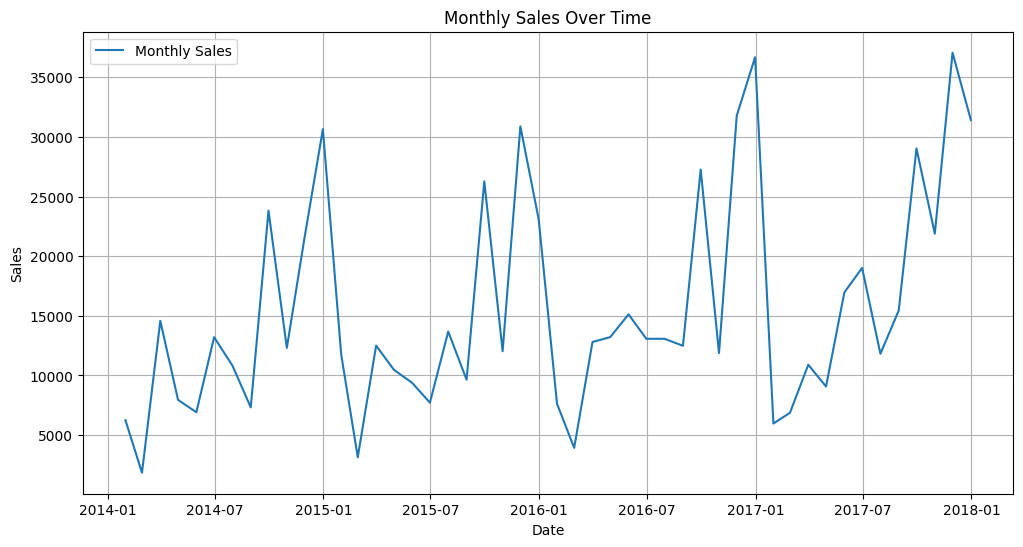

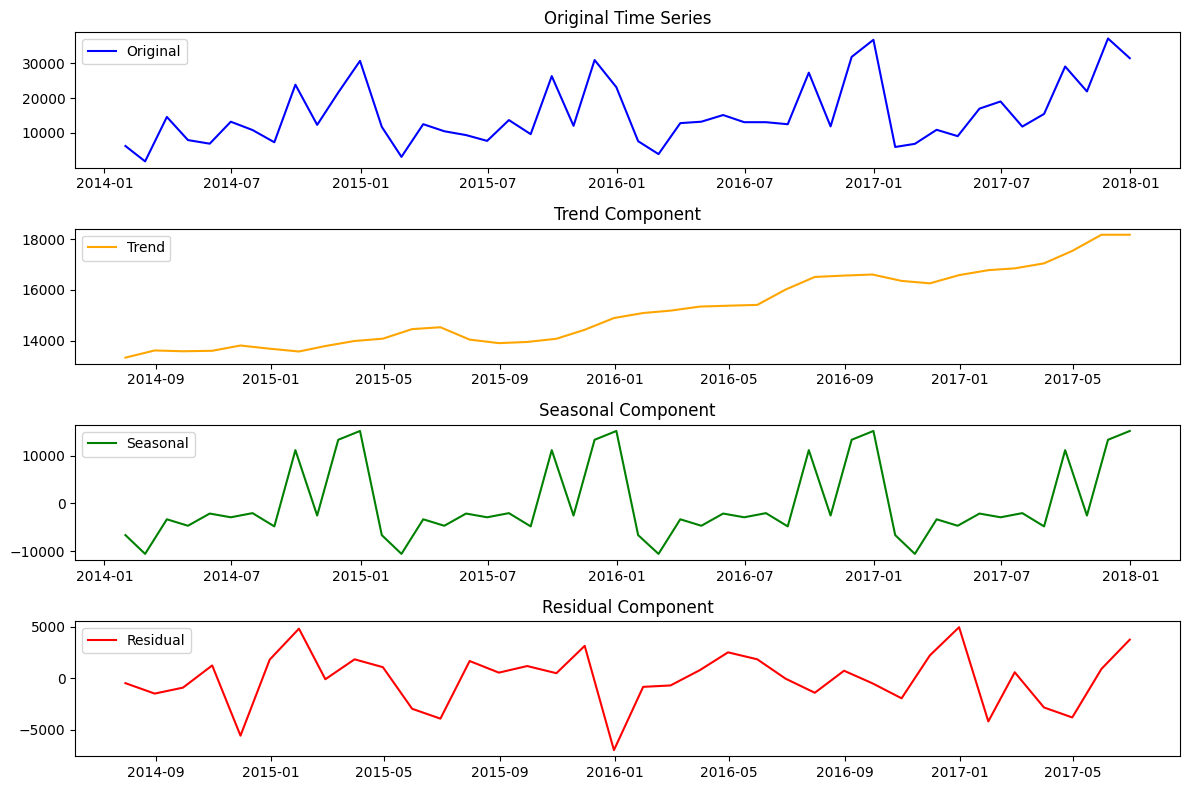

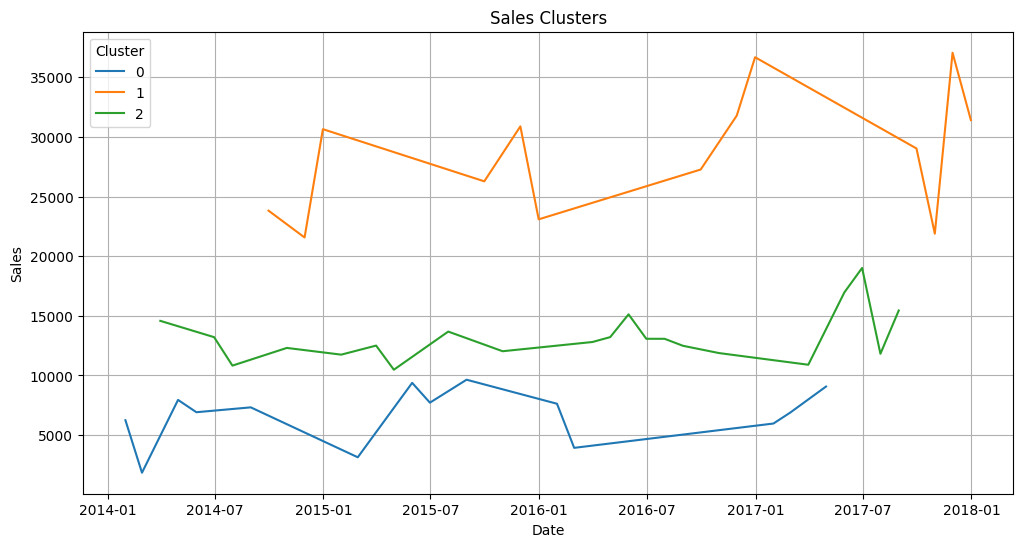

In [ ]:
# Import necessary libraries
import os
import json
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Set up Kaggle API credentials (replace with your Kaggle API key)
kaggle_json_path = '/content/kaggle.json'
os.environ['KAGGLE_CONFIG_DIR'] = '/content/'

# Set file permissions
!chmod 600 /content/kaggle.json

# Function to download dataset from Kaggle
def download_dataset():
    !kaggle datasets download -d tanayatipre/store-sales-forecasting-dataset -p /content/

# Download dataset
download_dataset()

# Unzip the dataset
with zipfile.ZipFile('/content/store-sales-forecasting-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Load the dataset
data_path = '/content/stores_sales_forecasting.csv'

# Try different encodings if needed
try:
    data = pd.read_csv(data_path, encoding='utf-8')
except UnicodeDecodeError:
    data = pd.read_csv(data_path, encoding='latin1')

# Display basic information about the dataset
print(data.info())
print(data.head())

# Convert 'Order Date' column to datetime format
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Set 'Order Date' as the index
data.set_index('Order Date', inplace=True)

# Resample the data to monthly frequency and sum sales
monthly_sales = data['Sales'].resample('M').sum()

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales, label='Monthly Sales')
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

# Decompose the time series to extract trend, seasonal, and residual components
decomposition = seasonal_decompose(monthly_sales, model='additive')
trend = decomposition.trend.dropna()
seasonal = decomposition.seasonal.dropna()
residual = decomposition.resid.dropna()

# Plot the decomposed components
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(monthly_sales, label='Original', color='blue')
plt.legend(loc='upper left')
plt.title('Original Time Series')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')
plt.title('Residual Component')

plt.tight_layout()
plt.show()

# Normalize sales data for clustering
scaler = MinMaxScaler()
normalized_sales = scaler.fit_transform(monthly_sales.values.reshape(-1, 1))

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)  # Set n_init explicitly
clusters = kmeans.fit_predict(normalized_sales)

# Convert Series to DataFrame for plotting
monthly_sales_clustered = pd.DataFrame(monthly_sales)
monthly_sales_clustered['Cluster'] = clusters

# Plot clusters
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales_clustered, x=monthly_sales_clustered.index, y='Sales', hue='Cluster', palette='tab10')
plt.title('Sales Clusters')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


2. Seasonal Decomposition

3. Visualize the Components

4. Interpret the Results
Trend: Observe the long-term movement in sales, which may indicate overall growth or decline.
Seasonality: Identify recurring patterns over specific periods (e.g., monthly, yearly).
Residuals: Analyze the irregular component, which represents noise or randomness not captured by the trend or seasonal components.

5. Potential Applications
Sales Forecasting: Understanding seasonal trends can help in predicting future sales and adjusting inventory.
Marketing Strategies: Identifying peak seasons can guide marketing campaigns and promotions.